In [114]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import os
from random import shuffle

In [115]:

def get_data(directory, dirs):

    max_jerks = []
    max_accs = []
    max_vels = []
    max_heights = []

    jerks = []
    accelerations = []
    velocities = []
    heights = []
    timestamps = []

    for filename in dirs:
        if filename.endswith('.csv'):
            file_path = os.path.join(directory, filename)
            
            df = pd.read_csv(file_path)
            
            max_jerk = df['aJerk'].abs().max()
            max_vel = df['aVelocity'].abs().max()
            max_acc = df['aAcc'].max()
            max_height = df['aHeight'].max()

            max_jerks.extend([max_jerk for i in range(len(df))])
            max_accs.extend([max_acc for i in range(len(df))])
            max_vels.extend([max_vel for i in range(len(df))])
            max_heights.extend([max_height for i in range(len(df))])

            jerks.extend(df['aJerk'].abs())
            accelerations.extend(df['aAcc'].abs())
            velocities.extend(df['aVelocity'].abs())
            heights.extend(df['aHeight'].abs())
            timestamps.extend(df['timestamps'])

    data = {
        "max_jerk": max_jerks,
        "max_acc": max_accs,
        "max_vel": max_vels,
        "max_height": max_heights,
        "jerks": jerks,
        "accelerations": accelerations,
        "velocities": velocities,
        "heights": heights,
        "timestamps": timestamps
        }   

    return pd.DataFrame(data)


In [116]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score


directory = './lr_data'
# Degree 4 with power 1 gives 86.5%
# Thats the highest I can get, appear to overfit drastically after any increase
# The range is massive tho, 86.5% was the highest I could get
dirs = os.listdir(directory)
shuffle(dirs)
test_size = 15
training_df = get_data(directory, dirs[:-test_size])
test_df = get_data(directory, dirs[-test_size:])

import warnings
warnings.filterwarnings("ignore")

predicting = 'jerks'
if predicting == 'heights':
    degree = 5
    power = 1
if predicting == 'velocities':
    degree = 5
    power = 1
if predicting == 'accelerations':
    degree = 6
    power = 1/2
if predicting == 'jerks': #No point, data is too noisy
    degree = 5
    power = 1

# for predicting in ['heights', 'velocities', 'accelerations']:
#     for degree in [3, 4, 5, 6, 7, 8]:
#         for power in [1, 1/2, 1/3]:
print("***MODEL****")
print(f"PREDICITING: {predicting}")
print(f"DEGREE: {degree}")
print(f"POWER: {power}")
# Define the polynomial model with Ridge regression
poly_model = make_pipeline(PolynomialFeatures(degree, include_bias=False), Ridge(alpha=0.85))

# Prepare training features and target variable
training_features = training_df[['timestamps', 'max_jerk', 'max_acc', 'max_vel', 'max_height']]
# Note: I AM ACCIDENTLY PUTTING TIMESTAMPS TO A POWER. NOT SURE OF THE IMPLICATIONS, IGNORE - MOVE ON
training_features = training_features.apply(lambda x: np.power(x, power))

# Apply RFE with the specified number of features
# poly_model = RFE(poly_model, n_features_to_select=3)

# Define the cross-validation strategy: 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation with RFE
cv_scores = cross_val_score(poly_model, training_features, training_df[predicting], cv=kf, scoring='neg_mean_squared_error')

# Convert the negative MSE scores to positive and calculate RMSE
mse_scores = -cv_scores
rmse_scores = np.sqrt(mse_scores)

print("Cross-validated MSE scores: ", mse_scores)
print("Cross-validated RMSE scores: ", rmse_scores)
print("Average RMSE: ", rmse_scores.mean())

# After cross-validation, fit the model on the entire training data
poly_model.fit(training_features, training_df[predicting])

# Prepare test features and make predictions
test_features = test_df[['timestamps', 'max_jerk', 'max_acc', 'max_vel', 'max_height']]
test_features = test_features.apply(lambda x: np.power(x, power))
test_df[f'predicted_{predicting}'] = poly_model.predict(test_features)

# Evaluate the model on the test set
print(f"Test set R^2 score: {poly_model.score(test_features, test_df[predicting])}")


***MODEL****
PREDICITING: accelerations
DEGREE: 6
POWER: 0.5
Cross-validated MSE scores:  [0.00854604 0.0085661  0.008562   0.00885263 0.00865086]
Cross-validated RMSE scores:  [0.09244481 0.09255322 0.09253105 0.09408844 0.09300999]
Average RMSE:  0.09292550268514052
Test set R^2 score: 0.8850470774386986


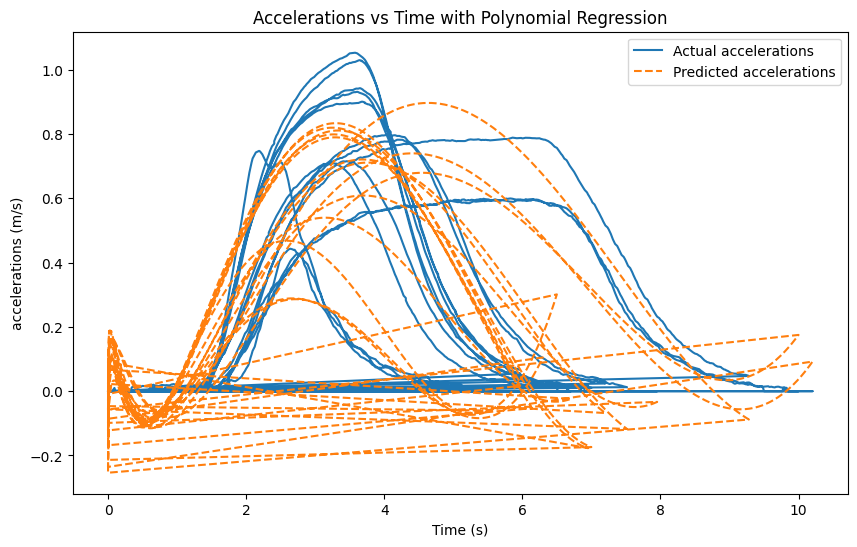

In [117]:
plt.figure(figsize=(10, 6))
plt.plot(test_df['timestamps'], test_df[predicting], label=f'Actual {predicting}')
plt.plot(test_df['timestamps'], test_df[f'predicted_{predicting}'], label=f'Predicted {predicting}', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel(f'{predicting} (m/s)')
plt.legend()
plt.title(f'{predicting.capitalize()} vs Time with Polynomial Regression')
plt.show()

In [118]:
poly_features = poly_model.named_steps['polynomialfeatures']
ridge_model = poly_model.named_steps['ridge']

coefficients = ridge_model.coef_
intercept = ridge_model.intercept_

# Construct the equation
feature_names = poly_features.get_feature_names_out()
equation = f"y = {intercept:.3f}"
for coef, name in zip(coefficients, feature_names):
    equation += f" + {coef:.3f} * {name}"

print("Ridge Regression Model Equation:")
print(equation)

Ridge Regression Model Equation:
y = 0.392 + -0.050 * timestamps + 0.010 * max_jerk + -0.007 * max_acc + -0.058 * max_vel + -0.028 * max_height + -2.088 * timestamps^2 + 0.104 * timestamps max_jerk + 0.013 * timestamps max_acc + 0.018 * timestamps max_vel + 0.147 * timestamps max_height + -0.030 * max_jerk^2 + -0.012 * max_jerk max_acc + -0.019 * max_jerk max_vel + 0.049 * max_jerk max_height + -0.010 * max_acc^2 + 0.060 * max_acc max_vel + 0.052 * max_acc max_height + -0.049 * max_vel^2 + -0.122 * max_vel max_height + -0.037 * max_height^2 + 2.835 * timestamps^3 + -1.000 * timestamps^2 max_jerk + -0.489 * timestamps^2 max_acc + 0.018 * timestamps^2 max_vel + -1.449 * timestamps^2 max_height + 0.064 * timestamps max_jerk^2 + 0.132 * timestamps max_jerk max_acc + -0.013 * timestamps max_jerk max_vel + 0.188 * timestamps max_jerk max_height + 0.149 * timestamps max_acc^2 + -0.013 * timestamps max_acc max_vel + -0.112 * timestamps max_acc max_height + 0.140 * timestamps max_vel^2 + 0.059 

In [119]:
import pandas as pd
from matplotlib import pyplot as plt
import os
from random import choice

In [120]:

def get_periods(result_file, buffer):
    with open("./results-a/" + result_file, "r") as f:
        df = pd.read_csv(f)

    period_dfs = []
    i = 0
    # collect_at_two = True
    previous_end = 0
    while i < len(df):

        period = []
        
        # Collect data until aStages is non-zero and there's at least one period element
        while i < len(df) and (df['aStages'].iloc[i] in [1, 3] or not len(period)):
            if df['aStages'].iloc[i] in [1, 3]:
                period.append([
                    df['timestamps'].iloc[i],
                    df['aAcc'].iloc[i],
                    df['aJerk'].iloc[i],
                    df['aVelocity'].iloc[i],
                    df['aHeight'].iloc[i]
                ])
            i += 1
        # twos = 0
        # while i < len(df) and (df['aStages'].iloc[i] != 0 or not period):

        #     if df['aStages'].iloc[i] != 0:
        #         period.append([
        #             df['timestamps'].iloc[i],
        #             df['aAcc'].iloc[i],
        #             df['aJerk'].iloc[i],
        #             df['aVelocity'].iloc[i],
        #             df['aHeight'].iloc[i]
        #         ])
            
        #     if collect_at_two and df['aStages'].iloc[i] == 2:
        #         twos += 1

        #     elif df['aStages'].iloc[i] == 3 and twos > 0:
                
        #         i -= int(twos / 2)
        #         period = period[:-int(twos / 2)]
        #         collect_at_two = False
        #         break

        #     i += 1

        # else:
        #     collect_at_two = True


        if not len(period) or i >= len(df): continue

        for j in range(max(0, i - len(period) - 1), max(i - len(period) - buffer, previous_end) - 1, -1):
            period.insert(0, [
                    df['timestamps'].iloc[j],
                    df['aAcc'].iloc[j],
                    df['aJerk'].iloc[j],
                    df['aVelocity'].iloc[j],
                    df['aHeight'].iloc[j]
                ])

        sliced_df = df.iloc[i + 1:]
        next_stage = sliced_df[sliced_df['aStages'].apply(lambda x: x in [1, 3])].index
        next_stage = len(df) - 1 if len(next_stage) == 0 else next_stage[0]

        for i in range(i, min(int((next_stage - i) / 2 + i), i + buffer)):
            period.append([
                    df['timestamps'].iloc[i],
                    df['aAcc'].iloc[i],
                    df['aJerk'].iloc[i],
                    df['aVelocity'].iloc[i],
                    df['aHeight'].iloc[i]
                ])

        previous_end = i

        period_df = pd.DataFrame(period, columns=['timestamps', 'aAcc', 'aJerk', 'aVelocity', 'aHeight'])

        period_df["jerks_direction"] = "up" if period_df['aJerk'].iloc[len(period_df) - 1] - period_df['aJerk'].iloc[0] > 0 else "down"
        period_df["accelerations_direction"] = "up" if period_df['aAcc'].iloc[int((len(period_df) - 1) / 2)] - period_df['aAcc'].iloc[0] > 0 else "down"
        period_df["velocities_direction"] = "up" if period_df['aVelocity'].iloc[len(period_df) - 1] - period_df['aVelocity'].iloc[0] > 0 else "down"
        period_df["heights_direction"] = "up" if period_df['aHeight'].iloc[len(period_df) - 1] - period_df['aHeight'].iloc[0] > 0 else "down"

        period_df["start_jerks"] = period_df['aJerk'].iloc[0]
        period_df["start_accelerations"] = period_df['aAcc'].iloc[0]
        period_df["start_velocities"] = period_df['aVelocity'].iloc[0]
        period_df["start_heights"] = period_df['aHeight'].iloc[0]

        period_df['actual_timestamps'] = period_df['timestamps']
        period_df['timestamps'] = period_df['timestamps'] - period_df['timestamps'].iloc[0]

        period_df['aJerk'] = period_df['aJerk'] - period_df['aJerk'].iloc[0]
        period_df['aJerk'] = abs(period_df['aJerk'])
        period_df['aJerk'] = np.where(period_df['aJerk'] < 0.01, 0, period_df['aJerk'])

        period_df['aAcc'] = period_df['aAcc'] - period_df['aAcc'].iloc[0]
        # period_df['aAcc'] = abs(period_df['aAcc'])
        period_df['aAcc'] = np.where(period_df['aAcc'].abs() < 0.01, 0, period_df['aAcc'])

        period_df['aVelocity'] = period_df['aVelocity'] - period_df['aVelocity'].iloc[0]
        period_df['aVelocity'] = abs(period_df['aVelocity'])
        period_df['aVelocity'] = np.where(period_df['aVelocity'] < 0.01, 0, period_df['aVelocity'])

        period_df['aHeight'] = period_df['aHeight'] - period_df['aHeight'].iloc[0]
        period_df['aHeight'] = abs(period_df['aHeight'])
        period_df['aHeight'] = np.where(period_df['aHeight'] < 0.01, 0, period_df['aHeight'])
        
        period_dfs.append(period_df)

    return period_dfs


In [121]:
def differentiate(df, u, v, new_name):
    assert u in df.columns, f"DataFrame must include {u}"
    assert v in df.columns, f"DataFrame must include {v}"
    df[new_name] = 0.0

    for i in range(1, len(df)):
        df.at[i, new_name] = df[new_name].iloc[i - 1]
        if df[u].iloc[i] == None or df[u].iloc[i - 1] == None:
            continue
        
        du = df[u].iloc[i] - df[u].iloc[i - 1]
        dv = df[v].iloc[i] - df[v].iloc[i - 1]

        if dv != 0:
            df.at[i, new_name] = du / dv


In [122]:
def integrate(df, u, v, new_name):
    assert u in df.columns, f"DataFrame must include {u}"
    assert v in df.columns, f"DataFrame must include {v}"
    df[new_name] = 0.0

    for i in range(1, len(df)):
        avg_u = (df[u].iloc[i] + df[u].iloc[i - 1]) / 2
        dv = df[v].iloc[i] - df[v].iloc[i - 1]
        
        df.at[i, new_name] = df[new_name].iloc[i - 1] + avg_u * dv

In [123]:

# have predicitng variable
var_map = {
    "heights": "aHeight",
    "accelerations": "aAcc",
    "velocities": "aVelocity",
    "jerks": "aJerk"
}
csv_header = var_map[predicting]

# result_file = "7337792618582923462"
result_file = choice(os.listdir("./results-a"))

df = pd.read_csv(os.path.join("./results-a/", result_file))

df['dAcc'] = 0
df['max_jerk'] = 0
df['max_acc'] = 0
df['max_vel'] = 0
df['max_height'] = 0

period_dfs = get_periods(result_file, 100)

for period_df in period_dfs:
    period_df['max_jerk'] = period_df['aJerk'].abs().max()
    period_df['max_vel'] = period_df['aVelocity'].abs().max()
    period_df['max_acc'] = period_df['aAcc'].abs().max()
    period_df['max_height'] = period_df['aHeight'].abs().max()
    draw_features = period_df[['timestamps', 'max_jerk', 'max_acc', 'max_vel', 'max_height']]
    draw_features = draw_features.apply(lambda x: np.power(x, power))
    period_df['predicted'] = poly_model.predict(draw_features)

    if period_df[f'{predicting}_direction'].iloc[0] == "down":
        period_df['predicted'] *= -1

    period_df['predicted'] = period_df['predicted'] + period_df[f'start_{predicting}'].iloc[0]

    # For calculating acc from vel
    differentiate(period_df, 'predicted', 'timestamps', 'dAcc')
    if period_df[f'accelerations_direction'].iloc[0] == "down":
        period_df['dAcc'] = np.where(period_df['dAcc'] > 0, 0, period_df['dAcc'])
    else:
        period_df['dAcc'] = np.where(period_df['dAcc'] < 0, 0, period_df['dAcc'])
    
    max_dAcc = period_df['dAcc'].abs().max()
    max_aAcc = period_df['aAcc'].abs().max()
    period_df['dAcc'] *= max_aAcc / max_dAcc

    for index, timestamp in enumerate(period_df['actual_timestamps']):
        indecies = df.index[df['timestamps'] == timestamp].tolist()
        df.at[indecies[0], 'dAcc'] = period_df['dAcc'].iloc[index]
        df.at[indecies[0], 'max_jerk'] = period_df['max_jerk'].iloc[0]
        df.at[indecies[0], 'max_acc'] = period_df['max_acc'].iloc[0]
        df.at[indecies[0], 'max_vel'] = period_df['max_vel'].iloc[0]
        df.at[indecies[0], 'max_height'] = period_df['max_height'].iloc[0]

    
    for j in range(indecies[0] - len(period_df), indecies[0]):
        if abs(df['dAcc'].iloc[j]) < 0.001:
            df.at[j, 'dAcc'] = df['dAcc'].iloc[j - 1]
        
    

# I have 374,400 data points


# Integrating to get the vels, and heights
integrate(df, 'dAcc', 'timestamps', 'dVelocity')
max_dVelocity = df['dVelocity'].abs().max()
max_aVelocity = df['aVelocity'].abs().max()
df['dVelocity'] *= max_aVelocity / max_dVelocity

# Only works for single journeys
integrate(df, 'dVelocity', 'timestamps', 'dHeight')
height_offset = df['aHeight'].iloc[len(df) - 1] - df['dHeight'].iloc[len(df) - 1]

for i in range(len(df) - 1, 0 , -1):
    if df['aStages'].iloc[i] != 0:
        end_time = df['timestamps'].iloc[i]
        break

# end_time = df['timestamps'].iloc[len(df) - 1]
time_offset = 0
for i in range(1, len(df)):
    if abs(df['dHeight'].iloc[i]) < 0.01:
        time_offset = df['timestamps'].iloc[i]
        df.at[i, 'dHeight'] = df['dHeight'].iloc[i - 1]
    elif time_offset and df['aStages'].iloc[i] == 0:
        df.at[i, 'dHeight'] = df['dHeight'].iloc[i - 1]
    else:
        t = (df['timestamps'].iloc[i] - time_offset) / (end_time - time_offset)
        df.at[i, 'dHeight'] = df['dHeight'].iloc[i] + height_offset * t
        


differentiate(df, 'dAcc', 'timestamps', 'dJerk')
for i in range(1, len(df)):
    df.at[i, 'dJerk'] = (df['dJerk'].iloc[i - 1] + 0.1 * df['dJerk'].iloc[i]) / 1.1
for i in range(len(df)):
    if abs(df['dJerk'].iloc[i]) > 0.1:
        if df['max_jerk'].iloc[i] == 0:
            df.at[i, 'dJerk'] = df['dJerk'].iloc[i - 1]
        else:
            df.at[i, 'dJerk'] = df['max_jerk'].iloc[i] * np.sign(df['dJerk'].iloc[i])
    else:
        df.at[i, 'dJerk'] = 0



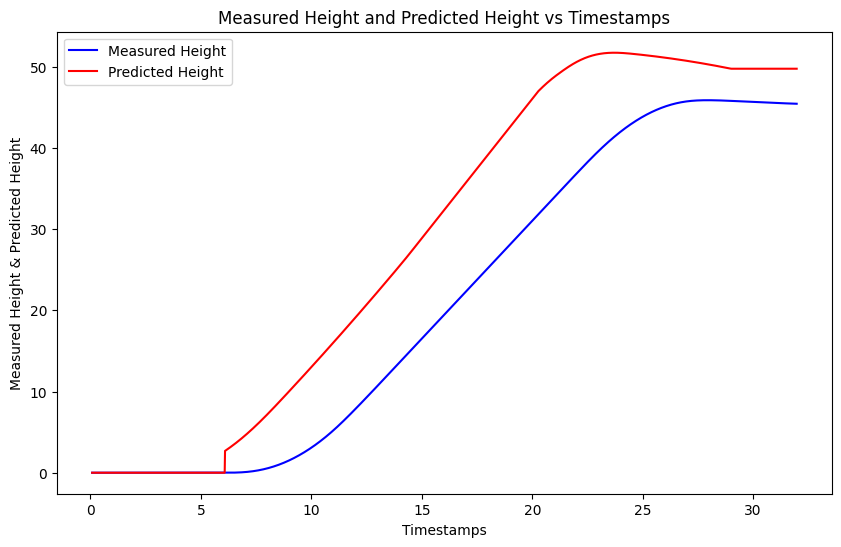

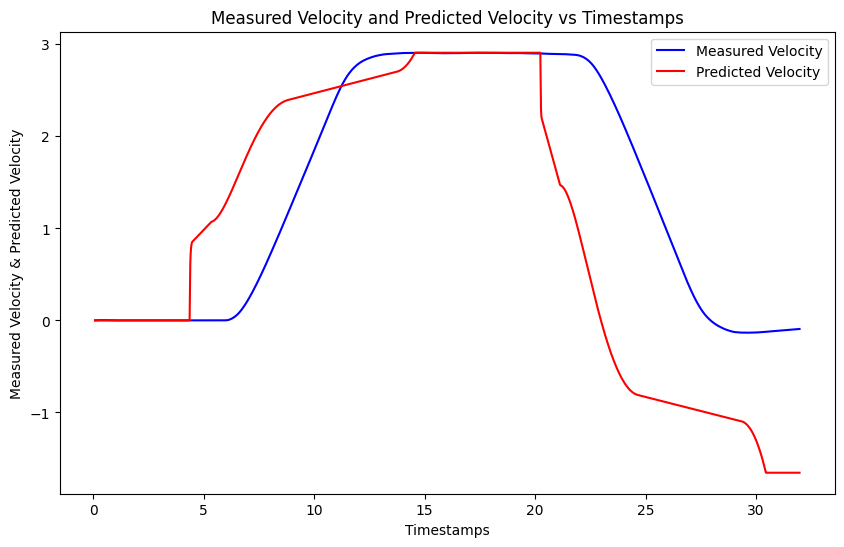

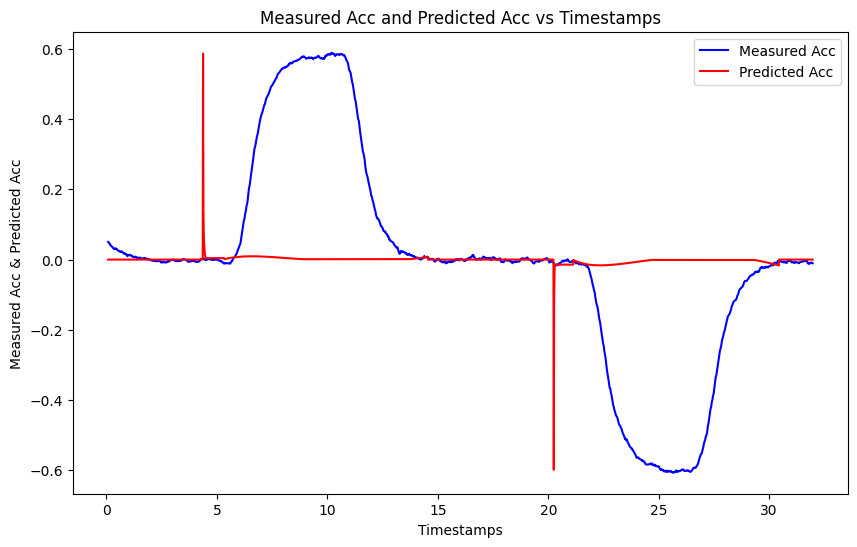

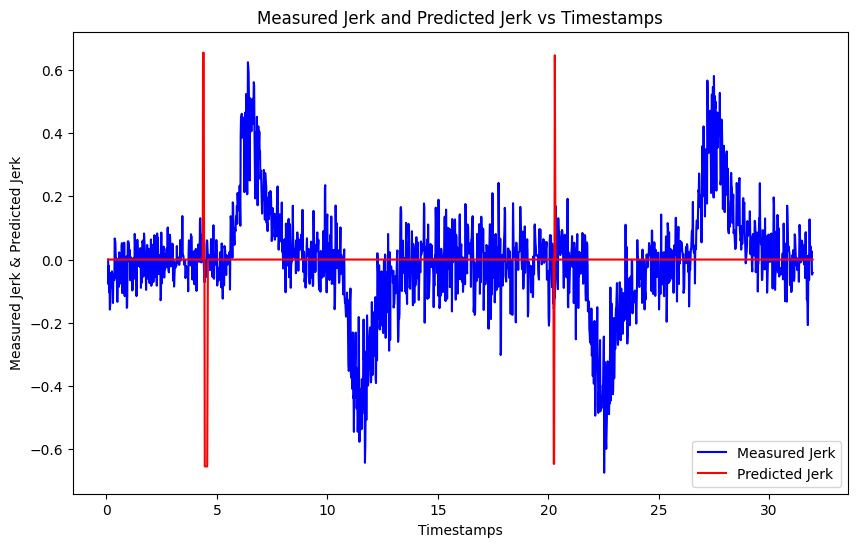

In [124]:
def chart(y1, y2):

    label_y1 = y1.replace("a", "Measured ")
    label_y2 = y2.replace("d", "Predicted ")

    plt.figure(figsize=(10, 6))

    # plt.plot(df['timestamps'], df[csv_header], label=predicting + " Actual", color='blue')

    # plt.plot(df['timestamps'][:len(df['best_fit'])], df['best_fit'], label=predicting + " Best Fit", color='red')

    plt.plot(df['timestamps'], df[y1], label=label_y1, color='blue')

    plt.plot(df['timestamps'][:len(df[y2])], df[y2], label=label_y2, color='red')

    # Adding titles and labels
    plt.title(f'{label_y1} and {label_y2} vs Timestamps')
    plt.xlabel('Timestamps')
    plt.ylabel(f"{label_y1} & {label_y2}")

    # Display the legend
    plt.legend()

    # Show the plot
    plt.show()

chart('aHeight', 'dHeight')
chart('aVelocity', 'dVelocity')
chart('aAcc', 'dAcc')
chart('aJerk', 'dJerk')